# Coordinate Transformations in Geopack

This notebook provides a comprehensive guide to using coordinate transformations in the geopack library, including both scalar and vectorized implementations.

## Table of Contents
1. [Overview of Coordinate Systems](#overview)
2. [Basic Usage](#basic-usage)
3. [Vectorized Transformations](#vectorized)
4. [Performance Comparison](#performance)
5. [Practical Examples](#examples)
6. [Visualization](#visualization)

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from mageometry import geopack
import time
from datetime import datetime

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

Load IGRF coefficients ...


## 1. Overview of Coordinate Systems <a name="overview"></a>

Geopack supports transformations between the following coordinate systems:

- **GEI** (Geocentric Equatorial Inertial): Earth-centered, fixed with respect to stars
- **GEO** (Geographic): Earth-centered, Earth-fixed, Z-axis along rotation axis
- **GSM** (Geocentric Solar Magnetospheric): X toward Sun, Z contains dipole
- **GSE** (Geocentric Solar Ecliptic): X toward Sun, Z perpendicular to ecliptic
- **SM** (Solar Magnetic): Z along dipole, Y perpendicular to Sun-Earth line
- **MAG** (Geomagnetic): Z along dipole, Earth-fixed
- **GSW** (Geocentric Solar Wind): Accounts for solar wind aberration

In [2]:
# Initialize geopack for a specific time
# This is REQUIRED before any coordinate transformations
ut = datetime(2020, 1, 1, 12, 0, 0).timestamp()
ps = geopack.recalc(ut)

print(f"Time: {datetime.fromtimestamp(ut)}")
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")

Time: 2020-01-01 12:00:00
Dipole tilt angle: -31.23 degrees


## 2. Basic Usage <a name="basic-usage"></a>

All coordinate transformation functions follow the same pattern:
- Input: `(x, y, z, j)` where `j > 0` for forward transformation, `j < 0` for reverse
- Output: `(x_out, y_out, z_out)` in the target coordinate system

In [3]:
# Example: Transform a point from GSM to GSE coordinates
x_gsm, y_gsm, z_gsm = 10.0, 5.0, 3.0  # Point in GSM coordinates (RE units)

# Forward transformation: GSM to GSE (j > 0)
x_gse, y_gse, z_gse = geopack.gsmgse(x_gsm, y_gsm, z_gsm, 1)
print(f"GSM: ({x_gsm:.2f}, {y_gsm:.2f}, {z_gsm:.2f})")
print(f"GSE: ({x_gse:.2f}, {y_gse:.2f}, {z_gse:.2f})")

# Reverse transformation: GSE back to GSM (j < 0)
x_gsm2, y_gsm2, z_gsm2 = geopack.gsmgse(x_gse, y_gse, z_gse, -1)
print(f"\nRound-trip GSM: ({x_gsm2:.2f}, {y_gsm2:.2f}, {z_gsm2:.2f})")
print(f"Round-trip error: {np.max(np.abs([x_gsm-x_gsm2, y_gsm-y_gsm2, z_gsm-z_gsm2]))}")

GSM: (10.00, 5.00, 3.00)
GSE: (10.00, 5.43, 2.12)

Round-trip GSM: (10.00, 5.00, 3.00)
Round-trip error: 0.0


In [4]:
# All available transformations
transformations = [
    ('gsmgse', 'GSM ↔ GSE'),
    ('geigeo', 'GEI ↔ GEO'),
    ('magsm', 'MAG ↔ SM'),
    ('smgsm', 'SM ↔ GSM'),
    ('geomag', 'GEO ↔ MAG'),
    ('geogsm', 'GEO ↔ GSM'),
    ('gswgsm', 'GSW ↔ GSM'),
]

# Test point
x, y, z = 8.0, 4.0, 2.0

print("Transformation Examples:")
print("=" * 50)
for func_name, desc in transformations:
    func = getattr(geopack, func_name)
    x_out, y_out, z_out = func(x, y, z, 1)
    print(f"{desc:15} ({x:.1f}, {y:.1f}, {z:.1f}) → ({x_out:.2f}, {y_out:.2f}, {z_out:.2f})")

Transformation Examples:
GSM ↔ GSE       (8.0, 4.0, 2.0) → (8.00, 4.28, 1.31)
GEI ↔ GEO       (8.0, 4.0, 2.0) → (-4.29, -7.85, 2.00)
MAG ↔ SM        (8.0, 4.0, 2.0) → (-8.92, 0.67, 2.00)
SM ↔ GSM        (8.0, 4.0, 2.0) → (5.80, 4.00, 5.86)
GEO ↔ MAG       (8.0, 4.0, 2.0) → (-1.74, 8.83, 1.74)
GEO ↔ GSM       (8.0, 4.0, 2.0) → (-3.49, -8.47, -0.09)
GSW ↔ GSM       (8.0, 4.0, 2.0) → (8.00, 4.00, 2.00)


## 3. Vectorized Transformations <a name="vectorized"></a>

All coordinate transformations have vectorized versions that can process arrays efficiently:

In [5]:
# Single point - returns scalars
x_single, y_single, z_single = geopack.gsmgse_vectorized(10.0, 5.0, 3.0, 1)
print(f"Single point result: ({x_single:.2f}, {y_single:.2f}, {z_single:.2f})")
print(f"Type: {type(x_single)}")

# Array of points - returns arrays
x_array = np.array([10.0, 5.0, -8.0, 12.0])
y_array = np.array([5.0, 10.0, -3.0, 0.0])
z_array = np.array([3.0, -2.0, 4.0, -5.0])

x_out, y_out, z_out = geopack.gsmgse_vectorized(x_array, y_array, z_array, 1)
print(f"\nArray result shape: {x_out.shape}")
print(f"X output: {x_out}")
print(f"Y output: {y_out}")
print(f"Z output: {z_out}")

Single point result: (10.00, 5.43, 2.12)
Type: <class 'float'>

Array result shape: (4,)
X output: [10.  5. -8. 12.]
Y output: [ 5.43007884  9.52677848 -2.29134738 -0.833362  ]
Z output: [ 2.12467498 -3.63874866  4.44406651 -4.93006164]


In [6]:
# Spherical-Cartesian conversions
# These are especially useful for plotting and analysis

# Convert from spherical to Cartesian
r = np.array([5.0, 10.0, 15.0])  # Radial distance
theta = np.array([0.0, np.pi/4, np.pi/2])  # Polar angle
phi = np.array([0.0, np.pi/2, np.pi])  # Azimuthal angle

x, y, z = geopack.sphcar_vectorized(r, theta, phi, 1)
print("Spherical to Cartesian:")
for i in range(len(r)):
    print(f"  r={r[i]:.1f}, θ={np.degrees(theta[i]):.0f}°, φ={np.degrees(phi[i]):.0f}° → "
          f"x={x[i]:.2f}, y={y[i]:.2f}, z={z[i]:.2f}")

# Convert back to spherical
r2, theta2, phi2 = geopack.sphcar_vectorized(x, y, z, -1)
print("\nRound-trip error (max):", np.max(np.abs(r - r2)))

Spherical to Cartesian:
  r=5.0, θ=0°, φ=0° → x=0.00, y=0.00, z=5.00
  r=10.0, θ=45°, φ=90° → x=0.00, y=7.07, z=7.07
  r=15.0, θ=90°, φ=180° → x=-15.00, y=0.00, z=0.00

Round-trip error (max): 0.0


## 4. Performance Comparison <a name="performance"></a>

Let's compare the performance of scalar vs vectorized implementations:

In [7]:
# Performance comparison function
def compare_performance(n_points, func_scalar, func_vector, func_name):
    # Generate random test points
    np.random.seed(42)
    x = np.random.uniform(-20, 20, n_points)
    y = np.random.uniform(-20, 20, n_points)
    z = np.random.uniform(-20, 20, n_points)
    
    # Time scalar version
    start = time.time()
    for i in range(n_points):
        func_scalar(x[i], y[i], z[i], 1)
    scalar_time = time.time() - start
    
    # Time vectorized version
    start = time.time()
    func_vector(x, y, z, 1)
    vector_time = time.time() - start
    
    speedup = scalar_time / vector_time
    
    return {
        'n_points': n_points,
        'scalar_time': scalar_time,
        'vector_time': vector_time,
        'speedup': speedup,
        'scalar_rate': n_points / scalar_time,
        'vector_rate': n_points / vector_time
    }

# Test different array sizes
sizes = [10, 100, 1000, 10000]
results = []

print("Performance Comparison: gsmgse transformation")
print("=" * 70)
print(f"{'N Points':>10} {'Scalar (s)':>12} {'Vector (s)':>12} {'Speedup':>10} {'Vector Rate':>15}")
print("-" * 70)

for n in sizes:
    result = compare_performance(n, geopack.gsmgse, geopack.gsmgse_vectorized, 'gsmgse')
    results.append(result)
    print(f"{n:10d} {result['scalar_time']:12.4f} {result['vector_time']:12.4f} "
          f"{result['speedup']:9.1f}x {result['vector_rate']:14.0f} pts/s")

Performance Comparison: gsmgse transformation
  N Points   Scalar (s)   Vector (s)    Speedup     Vector Rate
----------------------------------------------------------------------
        10       0.0000       0.0001       0.6x         183961 pts/s
       100       0.0001       0.0000       4.6x        4072140 pts/s
      1000       0.0007       0.0005       1.4x        2027213 pts/s
     10000       0.0088       0.0003      33.8x       38304146 pts/s


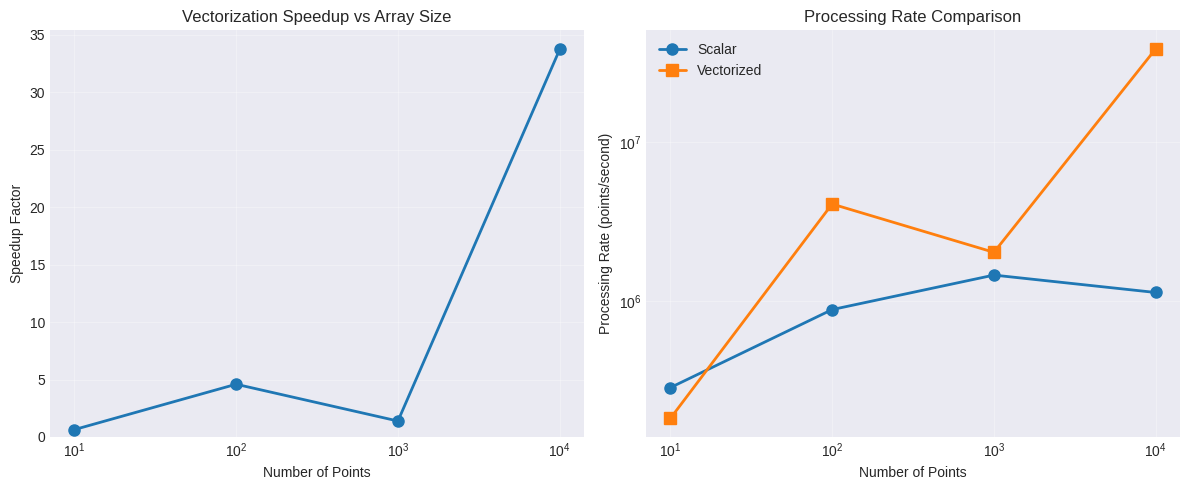

In [8]:
# Visualize performance scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Speedup vs array size
sizes_plot = [r['n_points'] for r in results]
speedups = [r['speedup'] for r in results]

ax1.semilogx(sizes_plot, speedups, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Speedup Factor')
ax1.set_title('Vectorization Speedup vs Array Size')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Processing rate
scalar_rates = [r['scalar_rate'] for r in results]
vector_rates = [r['vector_rate'] for r in results]

ax2.loglog(sizes_plot, scalar_rates, 'o-', label='Scalar', linewidth=2, markersize=8)
ax2.loglog(sizes_plot, vector_rates, 's-', label='Vectorized', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Points')
ax2.set_ylabel('Processing Rate (points/second)')
ax2.set_title('Processing Rate Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Practical Examples <a name="examples"></a>

### Example 1: Transform satellite orbit data

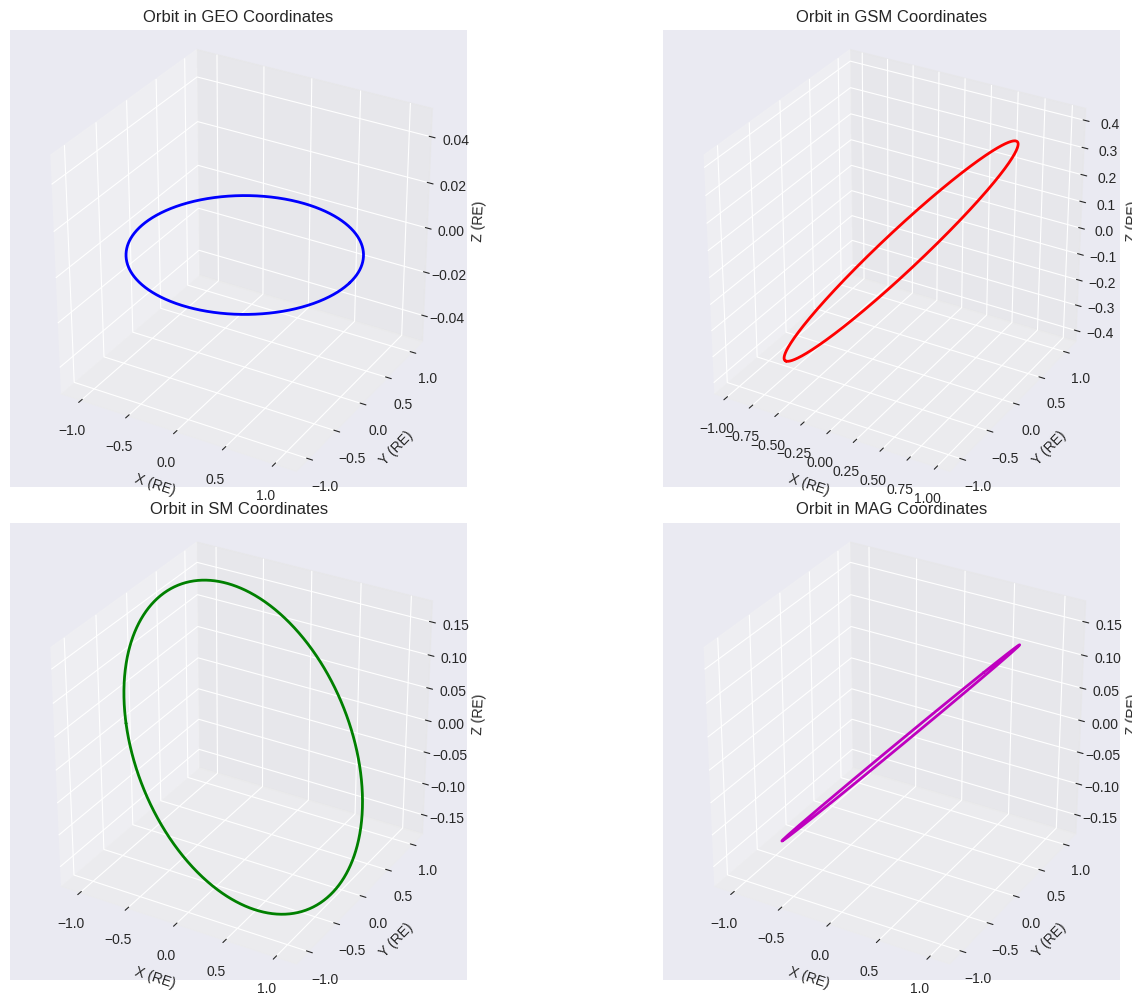

In [9]:
# Simulate satellite orbit in GEO coordinates
n_points = 1000
t = np.linspace(0, 2*np.pi, n_points)

# Circular orbit at 400 km altitude
r_orbit = 6378.137 + 400  # Earth radius + altitude in km
r_orbit_re = r_orbit / 6378.137  # Convert to RE units

# Orbit in GEO coordinates (equatorial)
x_geo = r_orbit_re * np.cos(t)
y_geo = r_orbit_re * np.sin(t)
z_geo = np.zeros_like(t)

# Transform to different coordinate systems
x_gsm, y_gsm, z_gsm = geopack.geogsm_vectorized(x_geo, y_geo, z_geo, 1)
x_sm, y_sm, z_sm = geopack.smgsm_vectorized(x_gsm, y_gsm, z_gsm, -1)
x_mag, y_mag, z_mag = geopack.geomag_vectorized(x_geo, y_geo, z_geo, 1)

# Plot orbits in different coordinate systems
fig = plt.figure(figsize=(15, 10))

# GEO coordinates
ax1 = fig.add_subplot(221, projection='3d')
ax1.plot(x_geo, y_geo, z_geo, 'b-', linewidth=2)
ax1.set_xlabel('X (RE)')
ax1.set_ylabel('Y (RE)')
ax1.set_zlabel('Z (RE)')
ax1.set_title('Orbit in GEO Coordinates')
ax1.set_box_aspect([1,1,1])

# GSM coordinates
ax2 = fig.add_subplot(222, projection='3d')
ax2.plot(x_gsm, y_gsm, z_gsm, 'r-', linewidth=2)
ax2.set_xlabel('X (RE)')
ax2.set_ylabel('Y (RE)')
ax2.set_zlabel('Z (RE)')
ax2.set_title('Orbit in GSM Coordinates')
ax2.set_box_aspect([1,1,1])

# SM coordinates
ax3 = fig.add_subplot(223, projection='3d')
ax3.plot(x_sm, y_sm, z_sm, 'g-', linewidth=2)
ax3.set_xlabel('X (RE)')
ax3.set_ylabel('Y (RE)')
ax3.set_zlabel('Z (RE)')
ax3.set_title('Orbit in SM Coordinates')
ax3.set_box_aspect([1,1,1])

# MAG coordinates
ax4 = fig.add_subplot(224, projection='3d')
ax4.plot(x_mag, y_mag, z_mag, 'm-', linewidth=2)
ax4.set_xlabel('X (RE)')
ax4.set_ylabel('Y (RE)')
ax4.set_zlabel('Z (RE)')
ax4.set_title('Orbit in MAG Coordinates')
ax4.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()

### Example 2: Field Component Transformations

In [10]:
# Example: Transform magnetic field components between coordinate systems
# This is essential when working with magnetometer data

# Sample magnetic field in spherical components at various locations
n_samples = 5
r = np.random.uniform(2, 10, n_samples)  # Distance in RE
theta = np.random.uniform(0, np.pi, n_samples)  # Polar angle
phi = np.random.uniform(0, 2*np.pi, n_samples)  # Azimuthal angle

# Magnetic field components in spherical coordinates (nT)
br = np.random.uniform(-100, 100, n_samples)
btheta = np.random.uniform(-50, 50, n_samples)
bphi = np.random.uniform(-30, 30, n_samples)

# Convert to Cartesian components
bx, by, bz = geopack.bspcar_vectorized(theta, phi, br, btheta, bphi)

# Get Cartesian positions
x, y, z = geopack.sphcar_vectorized(r, theta, phi, 1)

# Convert back to spherical to verify
br2, btheta2, bphi2 = geopack.bcarsp_vectorized(x, y, z, bx, by, bz)

print("Field Component Transformation Verification:")
print("=" * 60)
print("Original Spherical → Cartesian → Spherical")
for i in range(n_samples):
    print(f"\nPoint {i+1}:")
    print(f"  Position: r={r[i]:.2f}, θ={np.degrees(theta[i]):.1f}°, φ={np.degrees(phi[i]):.1f}°")
    print(f"  Original B: Br={br[i]:.1f}, Bθ={btheta[i]:.1f}, Bφ={bphi[i]:.1f} nT")
    print(f"  Cartesian: Bx={bx[i]:.1f}, By={by[i]:.1f}, Bz={bz[i]:.1f} nT")
    print(f"  Recovered: Br={br2[i]:.1f}, Bθ={btheta2[i]:.1f}, Bφ={bphi2[i]:.1f} nT")
    print(f"  Max error: {np.max(np.abs([br[i]-br2[i], btheta[i]-btheta2[i], bphi[i]-bphi2[i]])):.2e}")

Field Component Transformation Verification:
Original Spherical → Cartesian → Spherical

Point 1:
  Position: r=7.11, θ=126.0°, φ=156.8°
  Original B: Br=64.0, Bθ=45.1, Bφ=-1.5 nT
  Cartesian: Bx=-22.6, By=11.3, Bz=-74.2 nT
  Recovered: Br=64.0, Bθ=45.1, Bφ=-1.5 nT
  Max error: 7.11e-15

Point 2:
  Position: r=5.67, θ=148.6°, φ=322.4°
  Original B: Br=-94.8, Bθ=-6.4, Bφ=-17.2 nT
  Cartesian: Bx=-45.3, By=13.2, Bz=84.3 nT
  Recovered: Br=-94.8, Bθ=-6.4, Bφ=-17.2 nT
  Max error: 1.42e-14

Point 3:
  Position: r=9.72, θ=73.3°, φ=342.0°
  Original B: Br=-79.5, Bθ=-7.1, Bφ=16.4 nT
  Cartesian: Bx=-69.2, By=39.8, Bz=-16.1 nT
  Recovered: Br=-79.5, Bθ=-7.1, Bφ=16.4 nT
  Max error: 2.84e-14

Point 4:
  Position: r=3.75, θ=123.6°, φ=258.8°
  Original B: Br=32.3, Bθ=17.8, Bφ=-10.8 nT
  Cartesian: Bx=-13.9, By=-14.6, Bz=-32.7 nT
  Recovered: Br=32.3, Bθ=17.8, Bφ=-10.8 nT
  Max error: 7.11e-15

Point 5:
  Position: r=6.70, θ=54.6°, φ=134.8°
  Original B: Br=-41.8, Bθ=26.8, Bφ=-19.5 nT
  Cartesian:

### Example 3: Coordinate System Time Evolution

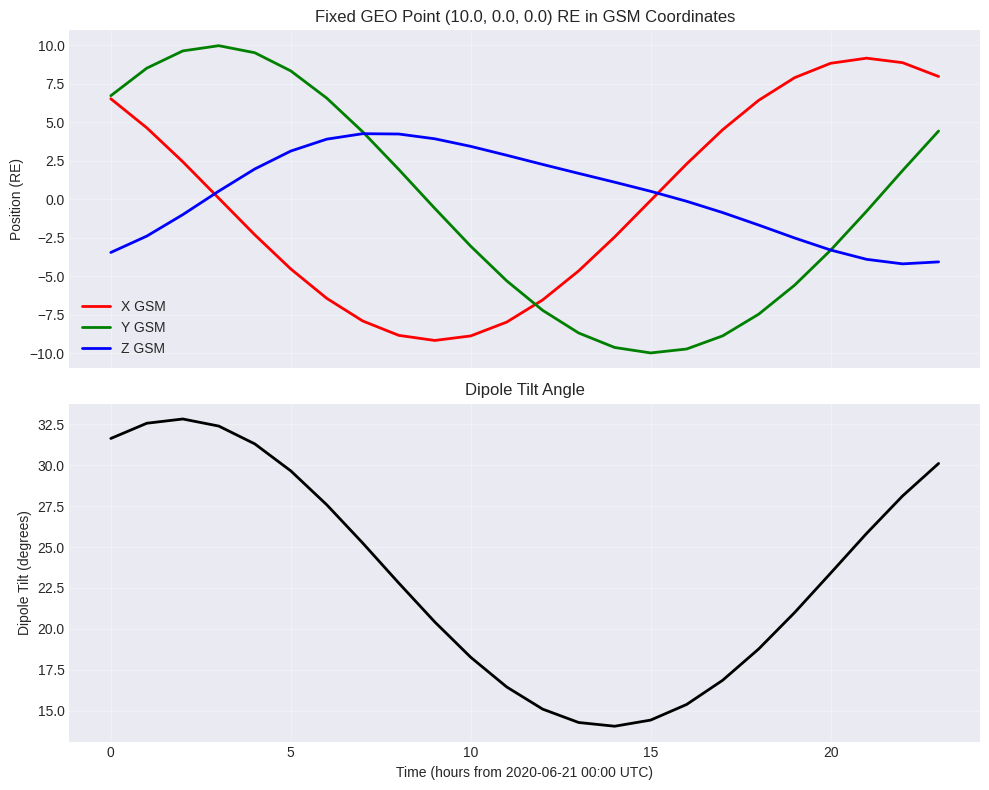

Over 24 hours:
  X_GSM range: -9.17 to 9.17 RE
  Y_GSM range: -9.99 to 9.99 RE
  Z_GSM range: -4.20 to 4.27 RE
  Dipole tilt range: 14.05° to 32.82°


In [11]:
# Show how coordinate transformations change over time
# This is important because Earth's rotation and dipole orientation change

# Fixed point in GEO coordinates
x_geo_fixed = 10.0
y_geo_fixed = 0.0
z_geo_fixed = 0.0

# Time range: 24 hours (0 to 23)
hours = np.linspace(0, 23, 24)
times = [datetime(2020, 6, 21, int(h), 0, 0).timestamp() for h in hours]

# Arrays to store results
x_gsm_time = []
y_gsm_time = []
z_gsm_time = []
dipole_tilts = []

for ut in times:
    # Must recalculate for each time
    ps = geopack.recalc(ut)
    dipole_tilts.append(np.degrees(ps))
    
    # Transform to GSM
    x_gsm, y_gsm, z_gsm = geopack.geogsm(x_geo_fixed, y_geo_fixed, z_geo_fixed, 1)
    x_gsm_time.append(x_gsm)
    y_gsm_time.append(y_gsm)
    z_gsm_time.append(z_gsm)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# GSM coordinates over time
ax1.plot(hours, x_gsm_time, 'r-', label='X GSM', linewidth=2)
ax1.plot(hours, y_gsm_time, 'g-', label='Y GSM', linewidth=2)
ax1.plot(hours, z_gsm_time, 'b-', label='Z GSM', linewidth=2)
ax1.set_ylabel('Position (RE)')
ax1.set_title(f'Fixed GEO Point ({x_geo_fixed}, {y_geo_fixed}, {z_geo_fixed}) RE in GSM Coordinates')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Dipole tilt angle
ax2.plot(hours, dipole_tilts, 'k-', linewidth=2)
ax2.set_xlabel('Time (hours from 2020-06-21 00:00 UTC)')
ax2.set_ylabel('Dipole Tilt (degrees)')
ax2.set_title('Dipole Tilt Angle')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Over 24 hours:")
print(f"  X_GSM range: {min(x_gsm_time):.2f} to {max(x_gsm_time):.2f} RE")
print(f"  Y_GSM range: {min(y_gsm_time):.2f} to {max(y_gsm_time):.2f} RE")
print(f"  Z_GSM range: {min(z_gsm_time):.2f} to {max(z_gsm_time):.2f} RE")
print(f"  Dipole tilt range: {min(dipole_tilts):.2f}° to {max(dipole_tilts):.2f}°")

## 6. Visualization <a name="visualization"></a>

### Visualize Coordinate System Orientations

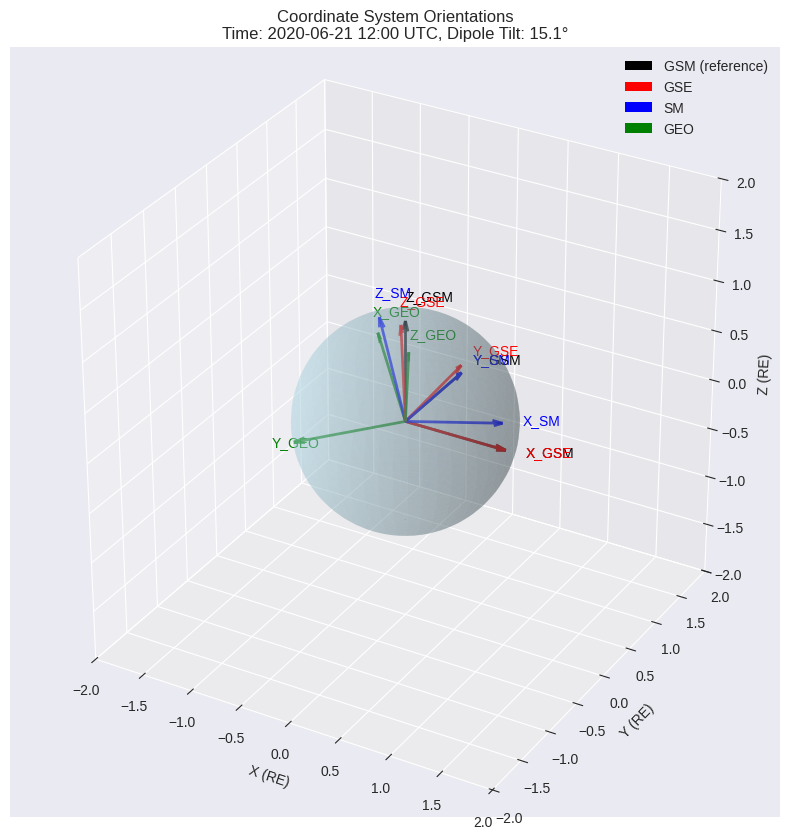

In [12]:
# Create unit vectors in GSM and transform to other systems
def plot_coordinate_axes(ax, transform_func, from_sys, to_sys, color, j=1):
    """Plot coordinate axes after transformation"""
    # Unit vectors
    origin = [0, 0, 0]
    
    # X, Y, Z unit vectors
    for i, (vec, label) in enumerate([
        ([1, 0, 0], 'X'),
        ([0, 1, 0], 'Y'), 
        ([0, 0, 1], 'Z')
    ]):
        # Transform the vector
        x, y, z = transform_func(vec[0], vec[1], vec[2], j)
        
        # Plot arrow
        ax.quiver(origin[0], origin[1], origin[2], 
                  x, y, z, 
                  color=color, arrow_length_ratio=0.1, 
                  linewidth=2, alpha=0.8)
        
        # Add label
        ax.text(x*1.2, y*1.2, z*1.2, f'{label}_{to_sys}', 
                fontsize=10, color=color)

# Set up the plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Initialize time
ut = datetime(2020, 6, 21, 12, 0, 0).timestamp()
ps = geopack.recalc(ut)

# Plot GSM axes (reference)
plot_coordinate_axes(ax, lambda x,y,z,j: (x,y,z), 'GSM', 'GSM', 'black')

# Plot other coordinate systems
systems = [
    (geopack.gsmgse, 'GSE', 'GSE', 'red', -1),
    (geopack.smgsm, 'SM', 'SM', 'blue', -1),
    (geopack.geogsm, 'GEO', 'GEO', 'green', -1),
]

for func, from_sys, to_sys, color, j in systems:
    plot_coordinate_axes(ax, func, from_sys, to_sys, color, j)

# Add Earth
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_earth = 1 * np.outer(np.cos(u), np.sin(v))
y_earth = 1 * np.outer(np.sin(u), np.sin(v))
z_earth = 1 * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_earth, y_earth, z_earth, alpha=0.3, color='lightblue')

# Set labels and title
ax.set_xlabel('X (RE)')
ax.set_ylabel('Y (RE)')
ax.set_zlabel('Z (RE)')
ax.set_title(f'Coordinate System Orientations\n'
            f'Time: 2020-06-21 12:00 UTC, Dipole Tilt: {np.degrees(ps):.1f}°')

# Set equal aspect ratio
ax.set_box_aspect([1,1,1])
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='GSM (reference)'),
    Patch(facecolor='red', label='GSE'),
    Patch(facecolor='blue', label='SM'),
    Patch(facecolor='green', label='GEO')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.show()